# Analyse des vulnérabilités ANSSI — Étapes 5 à 7

Ce notebook prolonge le pipeline (étapes 1-4 : extraction RSS/dump local →
identification des CVE → enrichissement MITRE/EPSS → CSV consolidé). Il couvre :

- **Étape 5** — exploration et visualisation du `data/consolidated.csv`.
- **Étape 6** — modèles de Machine Learning (2 supervisés + 3 non supervisés) confrontés entre eux.
- **Étape 7** — génération d'alertes email personnalisées pour les vulnérabilités critiques.

Périmètre des données : bulletins CERT-FR (avis + alertes) du `consolidated.csv` livré
(défini par `config.DEFAULT_YEARS` dans le pipeline).

### Démarche — pourquoi partir du CSV consolidé

**Choix** : on charge `data/consolidated.csv` (livrable 2) plutôt que de relancer
le pipeline d'extraction/enrichissement ici.

- *Pourquoi* : le CSV est l'unique source de l'analyse → le notebook est **rejouable
  à volonté** sans re-télécharger les bulletins ni ré-interroger MITRE/EPSS, et
  l'analyse reste **découplée** du code du pipeline.
- *Typage défensif* : un CSV est entièrement textuel et contient des `"Non disponible"`.
  On convertit donc `score_cvss`/`score_epss` en numérique et la date en `datetime`
  avec `errors="coerce"` → les valeurs non convertibles deviennent `NaN` au lieu de
  faire planter l'analyse.
- *Alternative écartée* : recalculer les données dans le notebook → lent, dépendant
  du réseau/dump, et mélange les responsabilités (pipeline vs analyse).

In [114]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

# Chargement BRUT : à ce stade tout est encore du texte (object).
df = pd.read_csv("data/consolidated.csv")
n_lignes_brut = len(df)

print("Lignes (couples bulletin × CVE) :", n_lignes_brut)
print("Colonnes :", len(df.columns))
print("\nTypes bruts (tout est 'object' = texte) :")
print(df.dtypes.to_string())
df.head()

Lignes (couples bulletin × CVE) : 125936
Colonnes : 14

Types bruts (tout est 'object' = texte) :
id_anssi                  str
titre_anssi               str
type_bulletin             str
date_publication          str
cve_id                    str
score_cvss            float64
base_severity             str
type_cwe                  str
score_epss            float64
lien_bulletin             str
description               str
editeur                   str
produit                   str
versions_affectees        str


,id_anssi,titre_anssi,type_bulletin,date_publication,cve_id,score_cvss,base_severity,type_cwe,score_epss,lien_bulletin,description,editeur,produit,versions_affectees
0,CERTFR-2023-AVI-0001,Vulnérabilité dans Apache Tomcat,Avis,2023-01-04T00:00:00.000000,CVE-2022-45143,NaN,Non disponible,CWE-116,0.00950,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,The JsonErrorReportValve in Apache Tomcat 8.5....,Apache Software Foundation,Apache Tomcat,"10.1.0-M1, 9.0.40, 8.5.83"
1,CERTFR-2023-AVI-0002,Multiples vulnérabilités dans les produits For...,Avis,2023-01-04T00:00:00.000000,CVE-2022-35845,7.6,Élevée,CWE-78,0.03866,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,Multiple improper neutralization of special el...,Fortinet,FortiTester,"7.1.0, 7.0.0, 4.2.0, 4.1.0, 4.0.0, 3.9.0, 3.8...."
2,CERTFR-2023-AVI-0002,Multiples vulnérabilités dans les produits For...,Avis,2023-01-04T00:00:00.000000,CVE-2022-39947,8.6,Élevée,CWE-78,0.01711,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,A improper neutralization of special elements ...,Fortinet,FortiADC,"7.0.0, 6.2.0, 6.1.0, 6.0.0, 5.4.0"
3,CERTFR-2023-AVI-0002,Multiples vulnérabilités dans les produits For...,Avis,2023-01-04T00:00:00.000000,CVE-2022-41336,6.6,Moyenne,CWE-79,0.00322,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,An improper neutralization of input during web...,Fortinet,FortiPortal,"6.0.0, 5.3.0, 5.2.0, 5.1.0, 5.0.0"
4,CERTFR-2023-AVI-0002,Multiples vulnérabilités dans les produits For...,Avis,2023-01-04T00:00:00.000000,CVE-2022-45857,6.0,Moyenne,CWE-286,0.00348,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,An incorrect user management vulnerability [CW...,Fortinet,FortiManager,"7.0.0, 6.4.0, 6.2.0"


## Nettoyage & préparation des données

### Démarche — d'où viennent les imperfections

Les données sont produites par un **enrichissement automatisé** agrégeant plusieurs
sources (bulletins ANSSI, API MITRE, API EPSS). Un CSV issu de ce flux présente des
imperfections typiques qu'on traite ici **avant** toute analyse :

1. **Types** — un CSV est entièrement textuel ; les scores et dates doivent être convertis.
2. **Valeurs manquantes / sentinelles** — tous les champs ne sont pas toujours renseignés
   (CVE sans CVSS, produit inconnu…).
3. **Doublons** — vérifier qu'aucune ligne n'est dupliquée par erreur.
4. **Plages de valeurs** — garantir CVSS ∈ [0,10] et EPSS ∈ [0,1].

> Note : le pipeline amont (`enrichment.py`) est déjà **défensif** (champ absent →
> `None`/`"Non disponible"`, jamais d'exception). Le nettoyage est donc surtout de la
> **validation + documentation** ; on le rend néanmoins explicite et reproductible ici.

### 2.1 — Typage

**Choix** : conversion avec `errors="coerce"`. *Pourquoi* : les colonnes numériques
contiennent des cellules vides ou textuelles (sentinelle) ; `coerce` transforme tout
ce qui n'est pas convertible en `NaN` propre **au lieu de lever une exception**. La
date est passée en `datetime` UTC, ce qui permet d'en dériver l'année.

In [115]:
df["score_cvss"] = pd.to_numeric(df["score_cvss"], errors="coerce")
df["score_epss"] = pd.to_numeric(df["score_epss"], errors="coerce")
df["date_publication"] = pd.to_datetime(df["date_publication"], errors="coerce", utc=True)
df["annee"] = df["date_publication"].dt.year

print("Types après conversion :")
print(df[["score_cvss", "score_epss", "date_publication", "annee"]].dtypes.to_string())

Types après conversion :
score_cvss                      float64
score_epss                      float64
date_publication    datetime64[us, UTC]
annee                             int32


### 2.2 — Valeurs manquantes & sentinelles

**Choix décisif** : on **conserve la sentinelle `"Non disponible"`** pour les colonnes
texte (CWE, éditeur, produit…) au lieu de la convertir en `NaN`.

- *Pourquoi* : elle distingue explicitement « **enrichissement absent** » d'une vraie
  valeur, et garde les graphiques catégoriels lisibles (une part « Non disponible »
  est une information en soi).
- *Alternative écartée* : tout passer en `NaN`. Cela uniformiserait le traitement mais
  ferait perdre cette distinction et compliquerait les filtres `!= "Non disponible"`
  utilisés dans toute la suite.
- Pour les colonnes **numériques**, l'absence est déjà un `NaN` (cf. 2.1).

In [116]:
na_num = df[["score_cvss", "score_epss"]].isna().mean().mul(100).round(1)
txt_cols = ["type_cwe", "editeur", "produit", "versions_affectees", "description"]
indispo = (df[txt_cols] == "Non disponible").mean().mul(100).round(1)

print("% NaN (colonnes numériques) :")
print(na_num.to_string())
print("\n% 'Non disponible' (colonnes texte) :")
print(indispo.to_string())

% NaN (colonnes numériques) :
score_cvss    61.7
score_epss     0.9

% 'Non disponible' (colonnes texte) :
type_cwe              76.5
editeur               10.1
produit                6.0
versions_affectees     2.6
description            0.9


### 2.3 — Doublons

**Choix** : on ne supprime **que les lignes strictement identiques** sur toutes les
colonnes.

- *Pourquoi* : une ligne = un couple (bulletin × CVE). Une même CVE citée par plusieurs
  bulletins apparaît **légitimement** plusieurs fois — c'est l'information d'exposition.
- *Alternative écartée* : `drop_duplicates("cve_id")` au niveau global détruirait cette
  information (on l'utilise ponctuellement pour les distributions, mais jamais comme
  nettoyage du jeu principal).

In [117]:
n_dups = df.duplicated().sum()
print("Lignes strictement dupliquées :", n_dups)
df = df.drop_duplicates().reset_index(drop=True)
print("Lignes après suppression :", len(df), f"(retirées : {n_lignes_brut - len(df)})")

Lignes strictement dupliquées : 0
Lignes après suppression : 125936 (retirées : 0)


### 2.4 — Validation des plages de valeurs

**Choix** : garde-fou explicite — CVSS doit rester dans [0,10] et EPSS dans [0,1].
Même si le pipeline ne devrait jamais produire de valeur hors-bornes, on **compte**
les anomalies puis on **borne** (`clip`) par sécurité (défense en profondeur).

In [118]:
hors_cvss = df["score_cvss"].dropna().between(0, 10).eq(False).sum()
hors_epss = df["score_epss"].dropna().between(0, 1).eq(False).sum()
print("Valeurs CVSS hors [0,10] :", hors_cvss)
print("Valeurs EPSS hors [0,1]  :", hors_epss)

df["score_cvss"] = df["score_cvss"].clip(0, 10)
df["score_epss"] = df["score_epss"].clip(0, 1)
print("→ Scores bornés (clip) par sécurité.")

Valeurs CVSS hors [0,10] : 0
Valeurs EPSS hors [0,1]  : 0
→ Scores bornés (clip) par sécurité.


### 2.5 — Normalisation du texte

**Choix** : retirer les espaces parasites en début/fin des colonnes texte. *Pourquoi* :
les valeurs éditeur/produit sont issues de concaténations (`" ; "`) ; un espace résiduel
créerait de faux doublons dans les classements (`"Microsoft"` ≠ `"Microsoft "`).

In [119]:
obj_cols = df.select_dtypes("object").columns
for col in obj_cols:
    df[col] = df[col].str.strip()
print("Colonnes texte normalisées :", list(obj_cols))

Colonnes texte normalisées : ['id_anssi', 'titre_anssi', 'type_bulletin', 'cve_id', 'base_severity', 'type_cwe', 'lien_bulletin', 'description', 'editeur', 'produit', 'versions_affectees']


### 2.6 — Récapitulatif

Le jeu est prêt pour l'analyse. Le faible nombre de corrections confirme que le
**pipeline amont était déjà robuste** : le nettoyage relève surtout du contrôle qualité.

In [120]:
print("Lignes (brut → propre) :", n_lignes_brut, "→", len(df))
print("Bulletins uniques :", df["id_anssi"].nunique())
print("CVE uniques :", df["cve_id"].nunique())
print(f"Mémoire : {df.memory_usage(deep=True).sum() / 1e6:.1f} Mo")
print("\nTypes finaux :")
print(df.dtypes.to_string())

Lignes (brut → propre) : 125936 → 125936
Bulletins uniques : 3915
CVE uniques : 37287
Mémoire : 249.1 Mo

Types finaux :
id_anssi                              str
titre_anssi                           str
type_bulletin                         str
date_publication      datetime64[us, UTC]
cve_id                                str
score_cvss                        float64
base_severity                         str
type_cwe                              str
score_epss                        float64
lien_bulletin                         str
description                           str
editeur                               str
produit                               str
versions_affectees                    str
annee                               int32


## Étape 5 — Exploration des données

### Démarche — deux niveaux de lecture

Une ligne = un couple (bulletin × CVE) : un bulletin multi-CVE est donc répété.
Ce détail impose un choix méthodologique selon la question posée :

- **Niveau vulnérabilité** (distribution des scores, types CWE…) → on dédoublonne
  sur `cve_id` (`df.drop_duplicates("cve_id")`). *Pourquoi* : une CVE citée par 50
  bulletins serait sinon comptée 50 fois et **biaiserait** les distributions.
- **Niveau bulletin / éditeur** (qui est le plus touché, avis vs alertes) → on garde
  **toutes** les lignes, car la répétition y est l'information (volume d'exposition).
- *Alternative écartée* : tout analyser sur les lignes brutes sans distinction →
  conclusions faussées sur la gravité moyenne et les types de failles.

In [121]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 125936 entries, 0 to 125935
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id_anssi            125936 non-null  str                
 1   titre_anssi         125936 non-null  str                
 2   type_bulletin       125936 non-null  str                
 3   date_publication    125936 non-null  datetime64[us, UTC]
 4   cve_id              125936 non-null  str                
 5   score_cvss          48213 non-null   float64            
 6   base_severity       125936 non-null  str                
 7   type_cwe            125936 non-null  str                
 8   score_epss          124828 non-null  float64            
 9   lien_bulletin       125936 non-null  str                
 10  description         125936 non-null  str                
 11  editeur             125936 non-null  str                
 12  produit             125936 

,id_anssi,titre_anssi,type_bulletin,date_publication,cve_id,score_cvss,base_severity,type_cwe,score_epss,lien_bulletin,description,editeur,produit,versions_affectees,annee
count,125936,125936,125936,125936,125936,48213.00000,125936,125936,124828.000000,125936,125936,125936,125936,119404,125936.000000
unique,3915,902,2,NaN,37287,NaN,5,505,NaN,3915,33232,721,4918,15730,NaN
top,CERTFR-2026-AVI-0326,Multiples vulnérabilités dans le noyau Linux d...,Avis,NaN,CVE-2023-44487,NaN,Non disponible,Non disponible,NaN,https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...,Non disponible,Linux,Linux,unspecified,NaN
freq,2293,29977,125769,NaN,72,NaN,77723,96294,NaN,2293,1125,74924,73811,3245,NaN
mean,NaN,NaN,NaN,2025-04-16 14:02:02.347859+00:00,NaN,6.69787,NaN,NaN,0.012906,NaN,NaN,NaN,NaN,NaN,2024.827698
min,NaN,NaN,NaN,2021-02-02 00:00:00+00:00,NaN,0.00000,NaN,NaN,0.000010,NaN,NaN,NaN,NaN,NaN,2021.000000
25%,NaN,NaN,NaN,2024-08-23 00:00:00+00:00,NaN,5.50000,NaN,NaN,0.000180,NaN,NaN,NaN,NaN,NaN,2024.000000
50%,NaN,NaN,NaN,2025-07-04 00:00:00+00:00,NaN,7.00000,NaN,NaN,0.000360,NaN,NaN,NaN,NaN,NaN,2025.000000
75%,NaN,NaN,NaN,2026-02-06 00:00:00+00:00,NaN,7.80000,NaN,NaN,0.000920,NaN,NaN,NaN,NaN,NaN,2026.000000
max,NaN,NaN,NaN,2026-06-09 00:00:00+00:00,NaN,10.00000,NaN,NaN,0.945170,NaN,NaN,NaN,NaN,NaN,2026.000000


In [122]:
# Vue au niveau vulnérabilité (1 ligne par CVE)
cve = df.drop_duplicates("cve_id").copy()
print("CVE uniques :", len(cve))
print("\nRépartition des gravités :")
print(cve["base_severity"].value_counts())
print("\nTop 10 éditeurs (par nb de couples bulletin×CVE) :")
print(df[df["editeur"] != "Non disponible"]["editeur"].value_counts().head(10))

CVE uniques : 37287

Répartition des gravités :
base_severity
Non disponible    13302
Élevée            10784
Moyenne           10348
Critique           1583
Faible             1270
Name: count, dtype: int64

Top 10 éditeurs (par nb de couples bulletin×CVE) :
editeur
Linux                         74924
Google                         4627
Microsoft                      4147
Oracle Corporation             3083
Apple                          1848
Red Hat                        1814
Apache Software Foundation     1313
OpenSSL                        1254
Mozilla                        1177
Go standard library            1161
Name: count, dtype: int64


## Étape 5 — Visualisations

### Démarche — chaque graphe répond à une question

On ne dessine pas pour dessiner : chaque visualisation cible une question de priorisation
(quelles vulns sont graves ? exploitables ? quels produits ? quelle dynamique ?). Choix
de représentation non triviaux :

- **Histogramme / countplot** pour les distributions (CVSS, gravité).
- **Camembert** pour le CWE : on veut la *part* de chaque type de faille dans un tout.
- **Échelle log** pour l'EPSS : la distribution est très asymétrique (la plupart des CVE
  ont un EPSS proche de 0, quelques-unes très élevé) → le log rend la courbe lisible.
- **Boxplot** pour la dispersion des CVSS par éditeur (médiane + étalement, pas juste une moyenne).
- Les distributions utilisent la vue **dédoublonnée `cve`** ; les classements éditeur/produit
  utilisent **`df`** complet (volume d'exposition).

#### Groupe 1 — Distributions (gravité & exploitabilité)

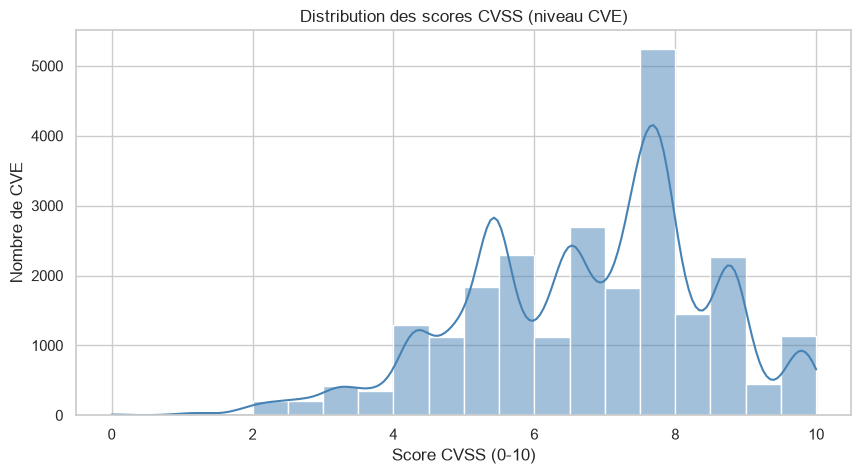

In [123]:
# 1) Histogramme des scores CVSS
plt.figure()
sns.histplot(cve["score_cvss"].dropna(), bins=20, kde=True, color="steelblue")
plt.title("Distribution des scores CVSS (niveau CVE)")
plt.xlabel("Score CVSS (0-10)"); plt.ylabel("Nombre de CVE")
plt.show()

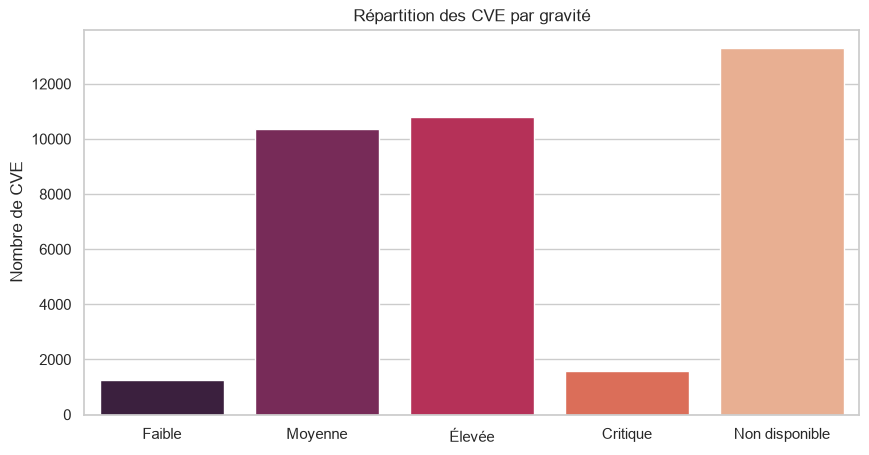

In [124]:
# 2) Répartition des gravités (base_severity)
order = ["Faible", "Moyenne", "Élevée", "Critique", "Non disponible"]
plt.figure()
sns.countplot(data=cve, x="base_severity", order=[o for o in order if o in cve["base_severity"].unique()],
              palette="rocket")
plt.title("Répartition des CVE par gravité")
plt.xlabel(""); plt.ylabel("Nombre de CVE")
plt.show()

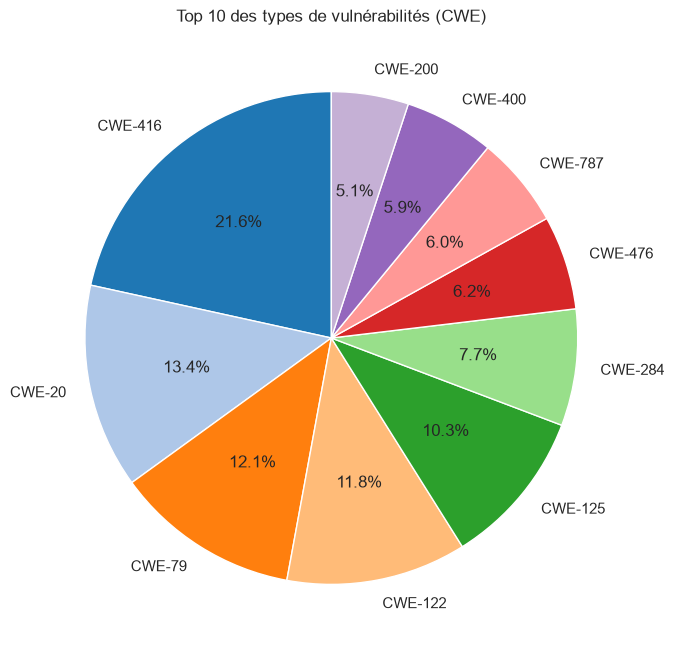

In [125]:
# 3) Camembert des types CWE les plus fréquents (top 10)
cwe_counts = cve[cve["type_cwe"] != "Non disponible"]["type_cwe"].value_counts().head(10)
plt.figure(figsize=(8, 8))
plt.pie(cwe_counts, labels=cwe_counts.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("tab20", len(cwe_counts)))
plt.title("Top 10 des types de vulnérabilités (CWE)")
plt.show()

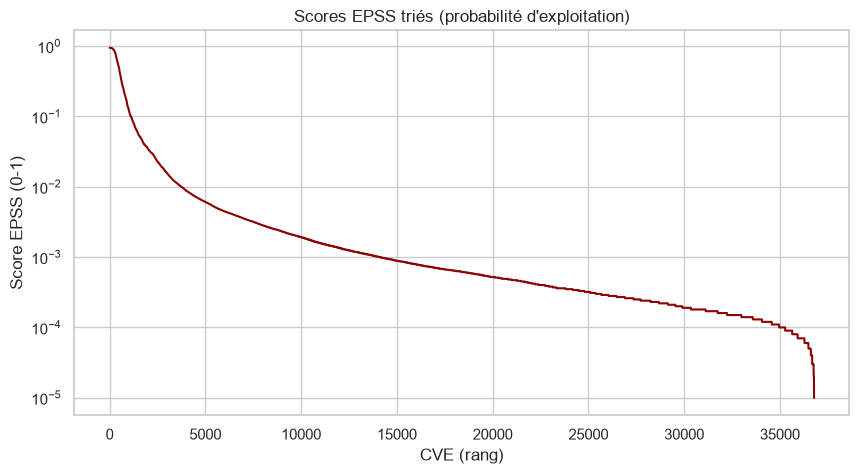

In [126]:
# 4) Courbe des scores EPSS triés (probabilité d'exploitation)
epss_sorted = cve["score_epss"].dropna().sort_values(ascending=False).reset_index(drop=True)
plt.figure()
plt.plot(epss_sorted.values, color="darkred")
plt.title("Scores EPSS triés (probabilité d'exploitation)")
plt.xlabel("CVE (rang)"); plt.ylabel("Score EPSS (0-1)")
plt.yscale("log")
plt.show()

#### Groupe 2 — Acteurs les plus exposés (éditeurs & produits)

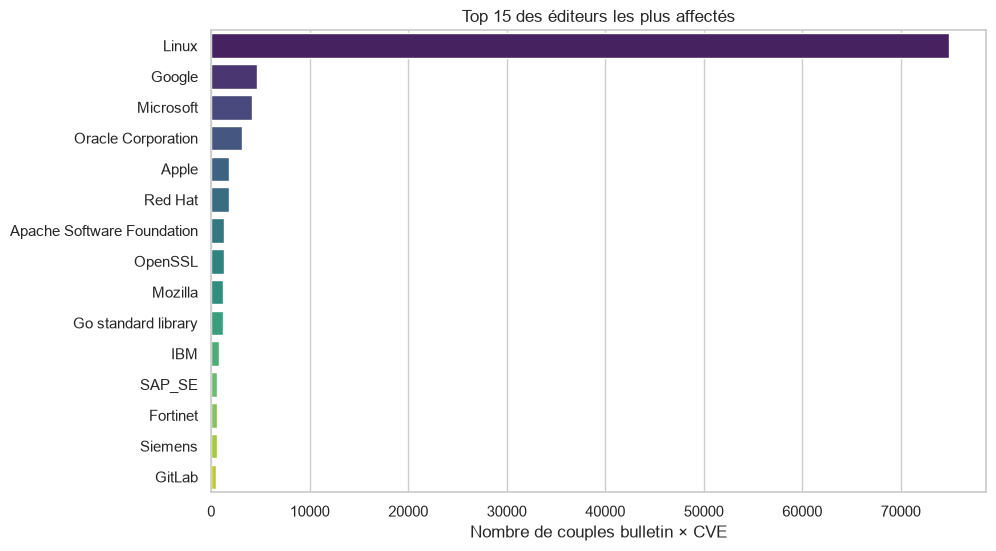

In [127]:
# 5) Top 15 éditeurs les plus affectés
top_ed = df[df["editeur"] != "Non disponible"]["editeur"].value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_ed.values, y=top_ed.index, palette="viridis")
plt.title("Top 15 des éditeurs les plus affectés")
plt.xlabel("Nombre de couples bulletin × CVE"); plt.ylabel("")
plt.show()

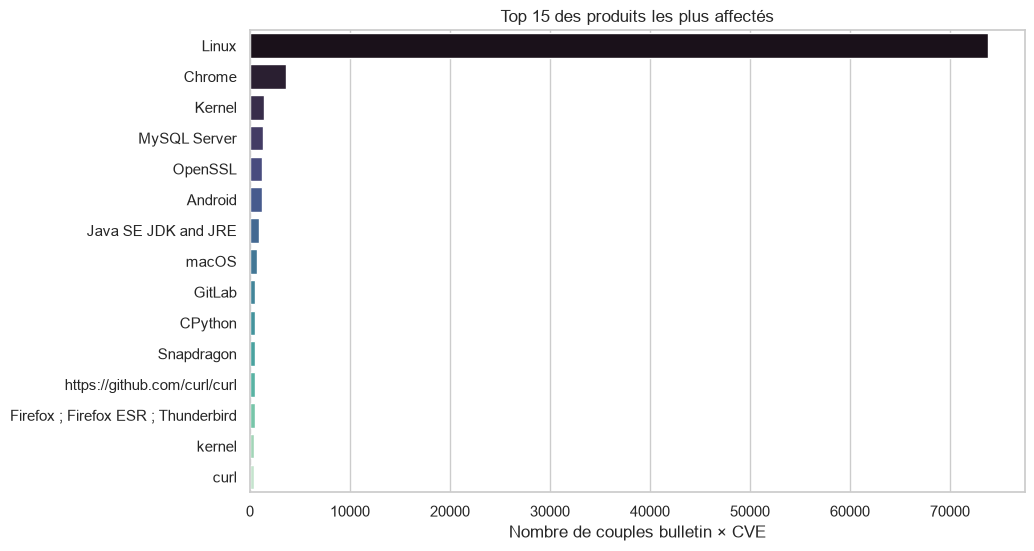

In [128]:
# 6) Top 15 produits les plus affectés
top_prod = df[df["produit"] != "Non disponible"]["produit"].value_counts().head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_prod.values, y=top_prod.index, palette="mako")
plt.title("Top 15 des produits les plus affectés")
plt.xlabel("Nombre de couples bulletin × CVE"); plt.ylabel("")
plt.show()

#### Groupe 3 — Relation gravité ↔ exploitabilité (CVSS vs EPSS)

Question clé de priorisation : une note de gravité élevée implique-t-elle une forte
probabilité d'exploitation ? La heatmap quantifie la corrélation, le nuage de points
en montre la forme (et révèle les CVE « graves mais peu exploitées » et inversement).

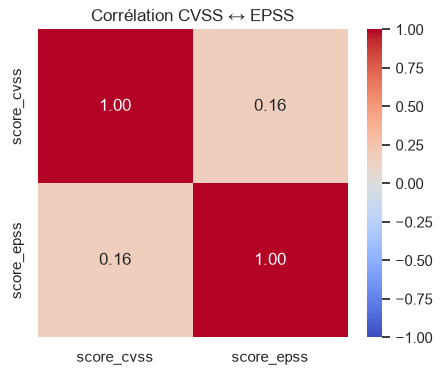

In [129]:
# 7) Heatmap de corrélation CVSS / EPSS
corr = cve[["score_cvss", "score_epss"]].dropna().corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Corrélation CVSS ↔ EPSS")
plt.show()

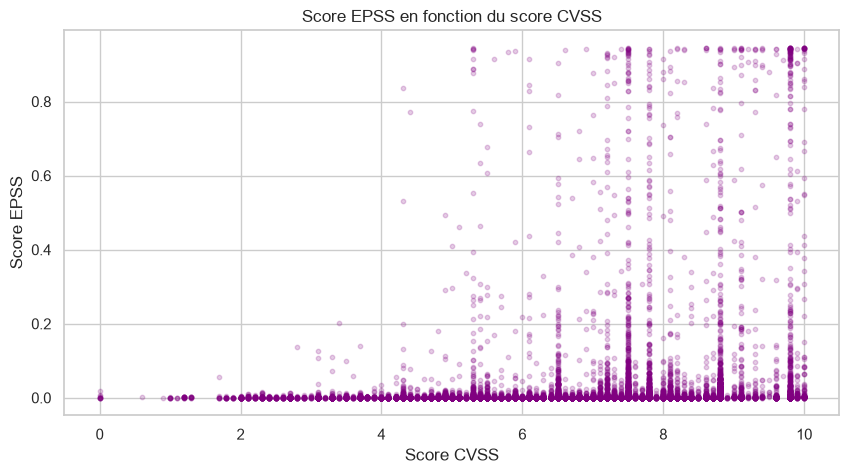

In [130]:
# 8) Nuage de points CVSS vs EPSS
sub = cve[["score_cvss", "score_epss"]].dropna()
plt.figure()
plt.scatter(sub["score_cvss"], sub["score_epss"], alpha=0.2, s=10, color="purple")
plt.title("Score EPSS en fonction du score CVSS")
plt.xlabel("Score CVSS"); plt.ylabel("Score EPSS")
plt.show()

#### Groupe 4 — Dynamique temporelle & dispersion par éditeur

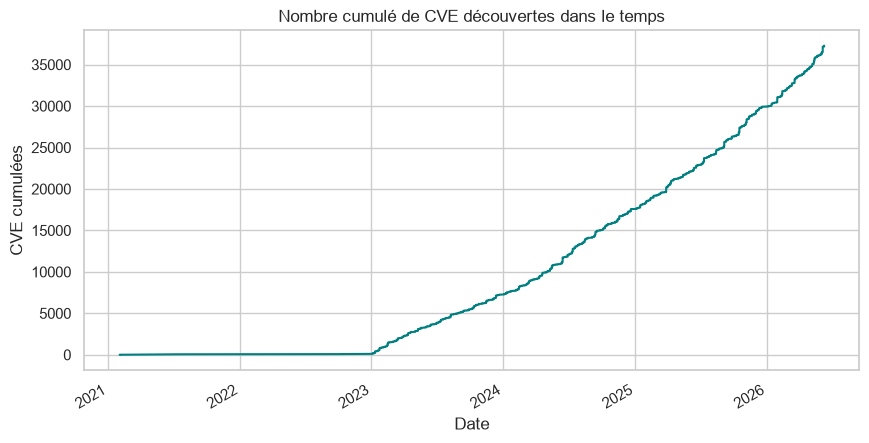

In [131]:
# 9) Courbe cumulative des vulnérabilités dans le temps
ts = df.drop_duplicates("cve_id").dropna(subset=["date_publication"]).sort_values("date_publication")
ts_cum = ts.set_index("date_publication").assign(n=1)["n"].cumsum()
plt.figure()
ts_cum.plot(color="teal")
plt.title("Nombre cumulé de CVE découvertes dans le temps")
plt.xlabel("Date"); plt.ylabel("CVE cumulées")
plt.show()

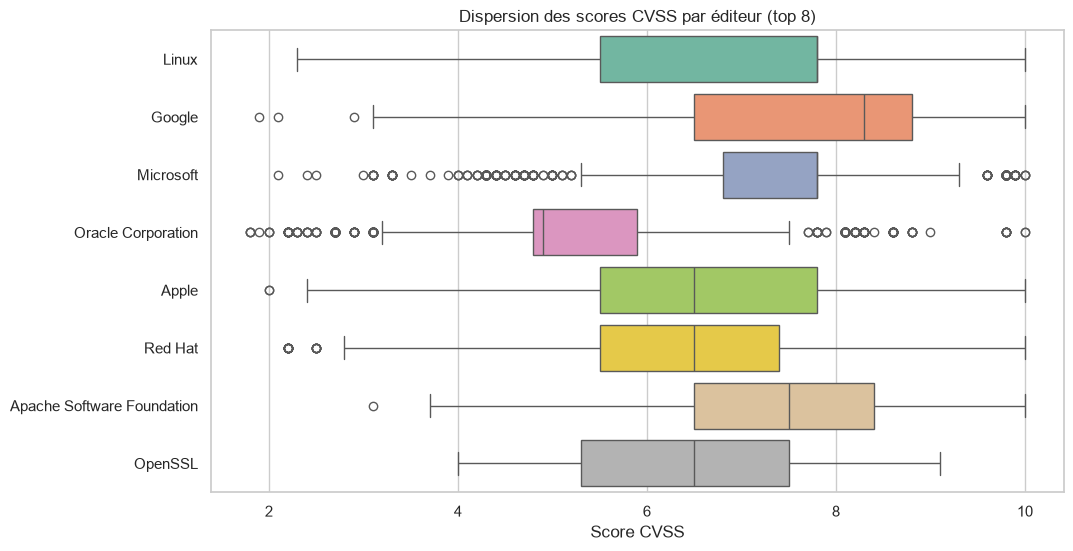

In [132]:
# 10) Boxplot des scores CVSS par éditeur (top 8 éditeurs)
top8 = df[df["editeur"] != "Non disponible"]["editeur"].value_counts().head(8).index
box = df[df["editeur"].isin(top8)].dropna(subset=["score_cvss"])
plt.figure(figsize=(11, 6))
sns.boxplot(data=box, x="score_cvss", y="editeur", order=top8, palette="Set2")
plt.title("Dispersion des scores CVSS par éditeur (top 8)")
plt.xlabel("Score CVSS"); plt.ylabel("")
plt.show()

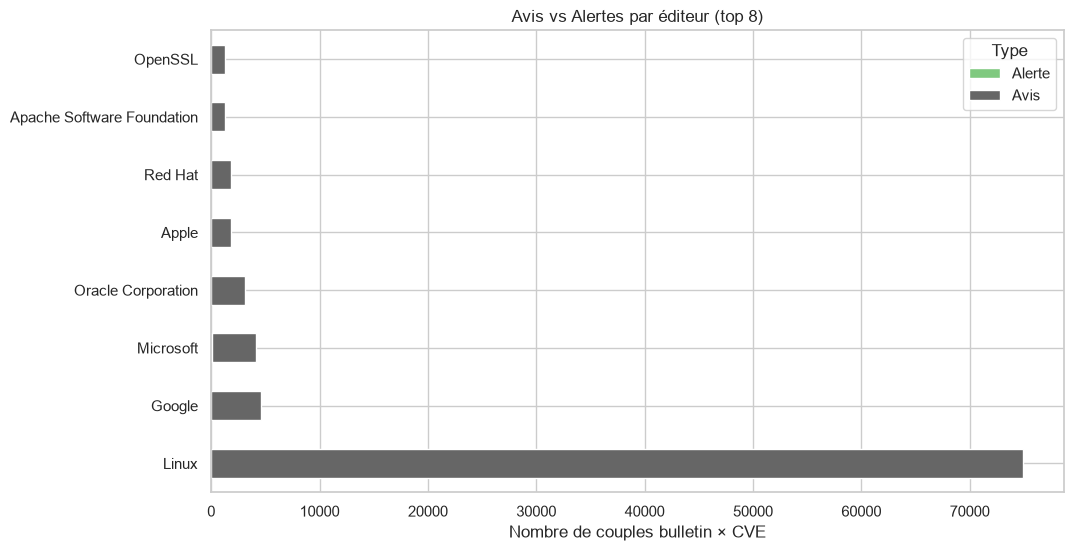

In [133]:
# 11) Vulnérabilités par éditeur et type de bulletin (avis vs alerte)
ct = (df[df["editeur"].isin(top8)]
      .groupby(["editeur", "type_bulletin"]).size().unstack(fill_value=0)
      .reindex(top8))
ct.plot(kind="barh", stacked=True, figsize=(11, 6), colormap="Accent")
plt.title("Avis vs Alertes par éditeur (top 8)")
plt.xlabel("Nombre de couples bulletin × CVE"); plt.ylabel("")
plt.legend(title="Type")
plt.show()

## Étape 6 — Machine Learning

**Démarche : confronter plusieurs modèles par famille.** Plutôt que de retenir un seul
algorithme, on en **compare deux (supervisé) et trois (non supervisé)** sur un protocole
**strictement identique** (mêmes données, même split, même métrique). L'objectif n'est pas
d'empiler les modèles mais de **les juger l'un contre l'autre** au regard de la question posée.

1. **Supervisé — classification de la gravité (`base_severity`).**
   Cible : Faible / Moyenne / Élevée / Critique. Variables explicatives : `score_epss`,
   `type_cwe`, `type_bulletin`, `editeur` (top-N).
   *Important :* on **n'utilise pas** `score_cvss` comme variable, car `base_severity`
   en est dérivée déterministe (fuite de cible). Question posée : peut-on prédire la
   gravité à partir d'autres signaux (probabilité d'exploitation, type de faille, éditeur) ?
   → **Confrontation : Random Forest (bagging) vs HistGradientBoosting (boosting).**

2. **Non supervisé — clustering** sur (`score_cvss`, `score_epss`) pour faire émerger des
   profils de risque (ex. critique & fortement exploitable).
   → **Confrontation : KMeans (centroïdes) vs GaussianMixture (probabiliste) vs DBSCAN (densité).**

In [134]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, silhouette_score, f1_score)

# Jeu d'apprentissage : 1 ligne par CVE, gravité connue.
ml = cve[cve["base_severity"] != "Non disponible"].copy()
ml = ml.dropna(subset=["score_epss"])

# Réduire la cardinalité : éditeur top-20, sinon 'Autre' ; CWE top-20.
def topn(s, n=20):
    top = s.value_counts().head(n).index
    return s.where(s.isin(top), "Autre")

ml["editeur_grp"] = topn(ml["editeur"])
ml["cwe_grp"] = topn(ml["type_cwe"])

features = pd.get_dummies(
    ml[["score_epss", "type_bulletin", "editeur_grp", "cwe_grp"]],
    columns=["type_bulletin", "editeur_grp", "cwe_grp"],
)
target = ml["base_severity"]
print("Échantillon ML :", features.shape, "| classes :", dict(target.value_counts()))

Échantillon ML : (23975, 45) | classes : {'Élevée': np.int64(10778), 'Moyenne': np.int64(10345), 'Critique': np.int64(1582), 'Faible': np.int64(1270)}


### Démarche — choix du modèle supervisé et de la métrique

- **Anti-fuite de cible (décision décisive)** : `base_severity` est une fonction
  *déterministe* de `score_cvss` (barème <4/<7/<9/≥9). L'utiliser comme variable
  donnerait ~100 % d'accuracy **sans rien apprendre**. On l'exclut → on teste si la
  gravité est prévisible à partir de signaux *indépendants* (EPSS, CWE, type, éditeur).
- *Alternatives écartées* : (a) **régression du CVSS** → R² flatteur mais contourne la
  vraie question ; (b) **CVSS en feature** → fuite triviale.
- **RandomForest** retenu : gère nativement le mélange numérique/catégoriel one-hot,
  capture les non-linéarités, et fournit l'**importance des variables** (interprétable).
  *Écartés* : régression logistique / SVM linéaire (moins adaptés au one-hot large et
  aux interactions, moins lisibles ici).
- `class_weight="balanced"` car les classes sont déséquilibrées (peu de Faible/Critique).
- Métrique = **F1-macro** : moyenne non pondérée sur les classes → l'accuracy serait
  trompeuse (un modèle prédisant toujours « Moyenne/Élevée » aurait une accuracy correcte
  mais raterait les classes rares qui nous intéressent).

In [135]:
# --- Supervisé : Random Forest ---
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.25, random_state=42, stratify=target)

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Rapport de classification (jeu de test) :\n")
print(classification_report(y_test, y_pred))

Rapport de classification (jeu de test) :

              precision    recall  f1-score   support

    Critique       0.24      0.41      0.30       396
      Faible       0.14      0.35      0.20       317
     Moyenne       0.62      0.55      0.58      2586
      Élevée       0.68      0.56      0.61      2695

    accuracy                           0.53      5994
   macro avg       0.42      0.47      0.42      5994
weighted avg       0.60      0.53      0.56      5994



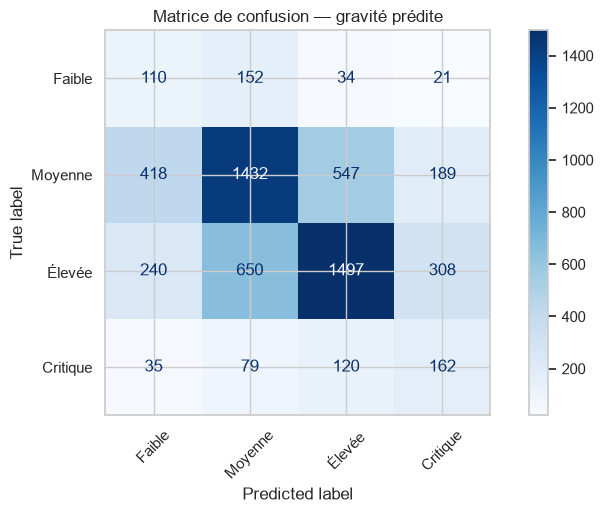

In [136]:
# Matrice de confusion
labels = ["Faible", "Moyenne", "Élevée", "Critique"]
labels = [l for l in labels if l in target.unique()]
cm = confusion_matrix(y_test, y_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matrice de confusion — gravité prédite")
plt.show()

F1-macro cross-val (5 folds) : 0.354 ± 0.011


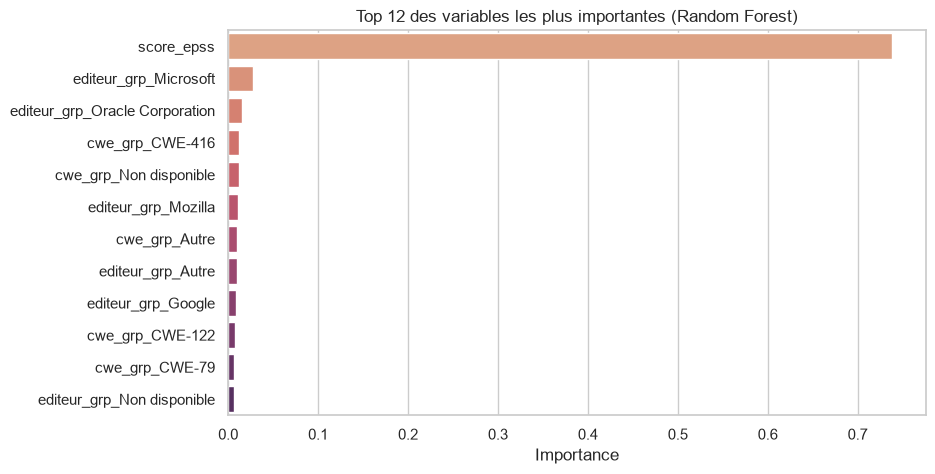

In [137]:
# Validation croisée + importance des variables
cv = cross_val_score(rf, features, target, cv=5, scoring="f1_macro", n_jobs=-1)
print(f"F1-macro cross-val (5 folds) : {cv.mean():.3f} ± {cv.std():.3f}")

imp = pd.Series(rf.feature_importances_, index=features.columns).sort_values(ascending=False).head(12)
plt.figure(figsize=(9, 5))
sns.barplot(x=imp.values, y=imp.index, palette="flare")
plt.title("Top 12 des variables les plus importantes (Random Forest)")
plt.xlabel("Importance"); plt.ylabel("")
plt.show()

### Démarche — 2ᵉ modèle supervisé : HistGradientBoosting (boosting vs bagging)

On confronte le Random Forest à un **boosting de gradient** sur arbres
(`HistGradientBoostingClassifier`). *Pourquoi ce choix* :

- **Même famille (arbres), stratégie opposée** : le RF est un **bagging** (arbres
  profonds entraînés en parallèle, vote moyenné → réduit la variance) ; le HGB est un
  **boosting** (petits arbres ajoutés séquentiellement, chacun corrigeant les erreurs du
  précédent → réduit le biais). La comparaison isole donc l'effet de la **stratégie
  d'apprentissage**, à features et protocole identiques.
- **Comparaison juste** : on réutilise **exactement** `X_train/X_test/y_train/y_test`
  (même split stratifié), la même métrique **F1-macro** et la même cross-val 5 folds.
- `class_weight="balanced"` également activé (déséquilibre Faible/Critique), comme pour le RF.
- *Attendu* : le boosting est souvent **plus performant** sur ce type de tâche ; on vérifie
  si le gain est réel **et stable** (cross-val) ou marginal.

In [138]:
# --- Supervisé n°2 : HistGradientBoosting (mêmes X_train/y_train que le RF) ---
hgb = HistGradientBoostingClassifier(random_state=42, class_weight="balanced")
hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)

print("Rapport de classification HGB (jeu de test) :\n")
print(classification_report(y_test, y_pred_hgb))

Rapport de classification HGB (jeu de test) :

              precision    recall  f1-score   support

    Critique       0.20      0.67      0.31       396
      Faible       0.13      0.62      0.21       317
     Moyenne       0.63      0.38      0.47      2586
      Élevée       0.75      0.45      0.56      2695

    accuracy                           0.44      5994
   macro avg       0.43      0.53      0.39      5994
weighted avg       0.63      0.44      0.49      5994



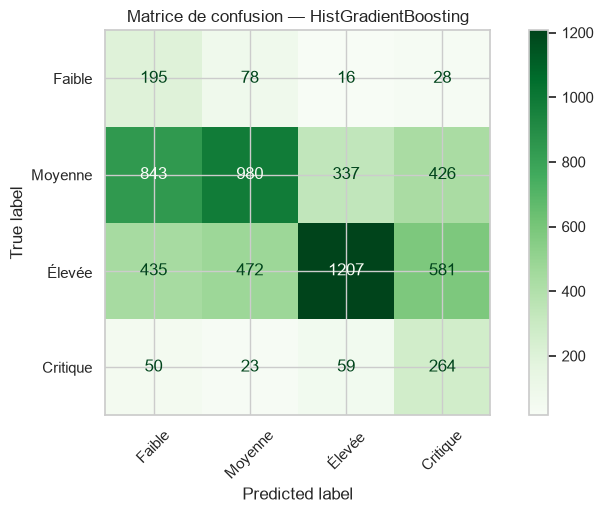

In [139]:
# Matrice de confusion HistGradientBoosting (mêmes labels que le RF)
cm_hgb = confusion_matrix(y_test, y_pred_hgb, labels=labels)
ConfusionMatrixDisplay(cm_hgb, display_labels=labels).plot(cmap="Greens", xticks_rotation=45)
plt.title("Matrice de confusion — HistGradientBoosting")
plt.show()

In [140]:
# Validation croisée HistGradientBoosting (même protocole que le RF)
cv_hgb = cross_val_score(hgb, features, target, cv=5, scoring="f1_macro", n_jobs=-1)
print(f"F1-macro cross-val HGB (5 folds) : {cv_hgb.mean():.3f} ± {cv_hgb.std():.3f}")

F1-macro cross-val HGB (5 folds) : 0.344 ± 0.005


Confrontation des modèles supervisés :
                      F1-macro (test)  F1-macro (CV 5 folds)  écart-type CV
Random Forest                   0.424                  0.354          0.011
HistGradientBoosting            0.389                  0.344          0.005


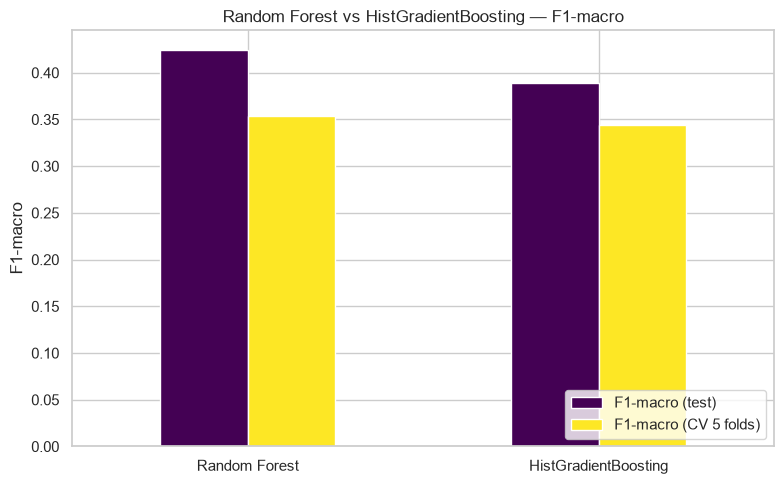

In [141]:
# --- Confrontation Random Forest vs HistGradientBoosting ---
# Même protocole pour les deux : on compare F1-macro (test) et F1-macro (cross-val 5 folds).
recap_sup = pd.DataFrame(
    {
        "F1-macro (test)": [
            f1_score(y_test, y_pred, average="macro"),
            f1_score(y_test, y_pred_hgb, average="macro"),
        ],
        "F1-macro (CV 5 folds)": [cv.mean(), cv_hgb.mean()],
        "écart-type CV": [cv.std(), cv_hgb.std()],
    },
    index=["Random Forest", "HistGradientBoosting"],
).round(3)
print("Confrontation des modèles supervisés :")
print(recap_sup.to_string())

ax = recap_sup[["F1-macro (test)", "F1-macro (CV 5 folds)"]].plot(
    kind="bar", figsize=(8, 5), colormap="viridis", rot=0)
ax.set_title("Random Forest vs HistGradientBoosting — F1-macro")
ax.set_ylabel("F1-macro"); ax.set_xlabel("")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Démarche — modèles non supervisés et protocole de comparaison

- Objectif : faire émerger des **profils de risque** en croisant gravité (CVSS) et
  exploitabilité (EPSS), sans étiquette.
- On **confronte trois approches** sur les **mêmes données standardisées** (`Xc`), jugées
  à la même aune (silhouette, nombre de clusters, lisibilité des profils) :
  - **KMeans** — centroïdes, clusters globulaires, **k fixe**. Rapide, profils lisibles
    (centres = profils types).
  - **GaussianMixture** — modèle **probabiliste**, clusters **elliptiques** + assignation
    souple. Plus flexible sur la forme des groupes ; comparable via silhouette et BIC.
  - **DBSCAN** — fondé sur la **densité** : **pas de k imposé**, détecte automatiquement le
    **bruit / les outliers**. Paradigme radicalement différent ; sensible à `eps`, qu'on
    choisit via le graphe des k-distances.
  - *Écarté* : **clustering agglomératif** (coût mémoire/temps prohibitif à ~30k points).
- **Standardisation** obligatoire : CVSS ∈ [0,10] et EPSS ∈ [0,1] → sans mise à l'échelle,
  le CVSS dominerait la distance euclidienne.
- Choix de **k** (pour KMeans/GMM) par **coude (inertie)** + **silhouette**. La silhouette
  favorise k=2 (séparation nette), mais on retient **k=4** pour des profils plus
  *actionnables* (ex. « critique & très exploitable » vs « grave mais peu exploité ») —
  compromis finesse/interprétabilité assumé.

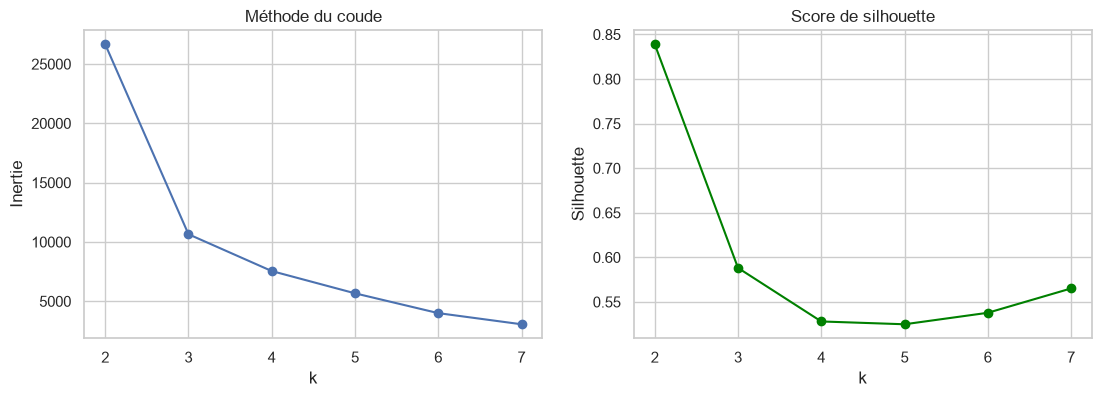

Silhouette par k : {2: 0.839, 3: 0.588, 4: 0.528, 5: 0.525, 6: 0.538, 7: 0.565}


In [142]:
# --- Non supervisé : KMeans sur (CVSS, EPSS) ---
clu = cve.dropna(subset=["score_cvss", "score_epss"])[["score_cvss", "score_epss"]].copy()
Xc = StandardScaler().fit_transform(clu)

# Choix de k : méthode du coude + silhouette
inertias, sils, ks = [], [], range(2, 8)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xc)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xc, km.labels_, sample_size=10000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), inertias, "o-"); ax[0].set_title("Méthode du coude"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertie")
ax[1].plot(list(ks), sils, "o-", color="green"); ax[1].set_title("Score de silhouette"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette")
plt.show()
print("Silhouette par k :", {k: round(s, 3) for k, s in zip(ks, sils)})

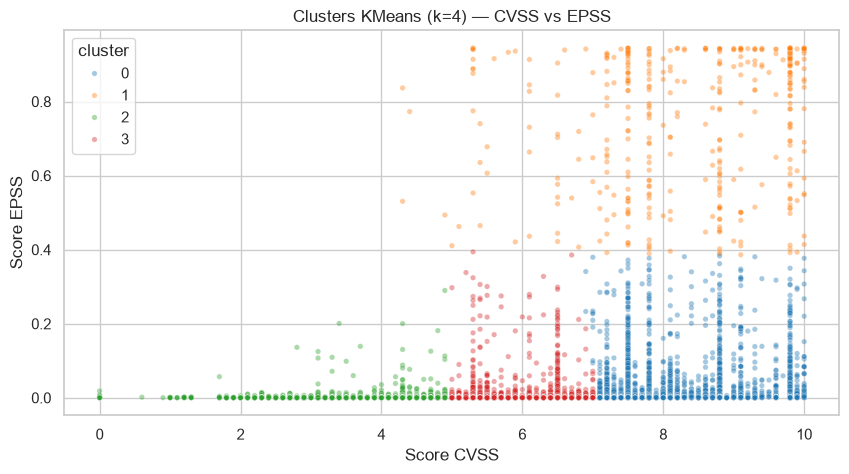

Profil moyen par cluster :
        score_cvss        score_epss       
              mean  count       mean  count
cluster                                    
0            8.130  11592      0.011  11592
1            8.409    417      0.757    417
2            3.979   3679      0.002   3679
3            5.995   8287      0.004   8287


In [143]:
# KMeans final (k=4) + interprétation des clusters
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xc)
clu["cluster"] = km.labels_

plt.figure()
sns.scatterplot(data=clu, x="score_cvss", y="score_epss", hue="cluster",
                palette="tab10", alpha=0.4, s=15)
plt.title(f"Clusters KMeans (k={k}) — CVSS vs EPSS")
plt.xlabel("Score CVSS"); plt.ylabel("Score EPSS")
plt.show()

print("Profil moyen par cluster :")
print(clu.groupby("cluster")[["score_cvss", "score_epss"]].agg(["mean", "count"]).round(3))

### Non supervisé n°2 — GaussianMixture (clustering probabiliste)

On confronte KMeans à un **modèle de mélange gaussien** (même k=4, mêmes données `Xc`).
*Différence clé* :

- **KMeans** suppose des clusters **sphériques** de taille comparable (distance au centroïde) ;
- **GMM** modélise chaque cluster par une **gaussienne** (covariance `full`) → clusters
  **elliptiques/étirés** et **assignation souple** (probabilité d'appartenance), mieux
  adaptés à des nuages allongés comme (CVSS, EPSS).

Comparaison via la **silhouette** (même protocole que KMeans) et le **BIC** (critère
d'information du modèle : plus bas = meilleur compromis ajustement/complexité).

Silhouette GMM (k=4) : -0.073
BIC (plus bas = meilleur ajustement) : -45309


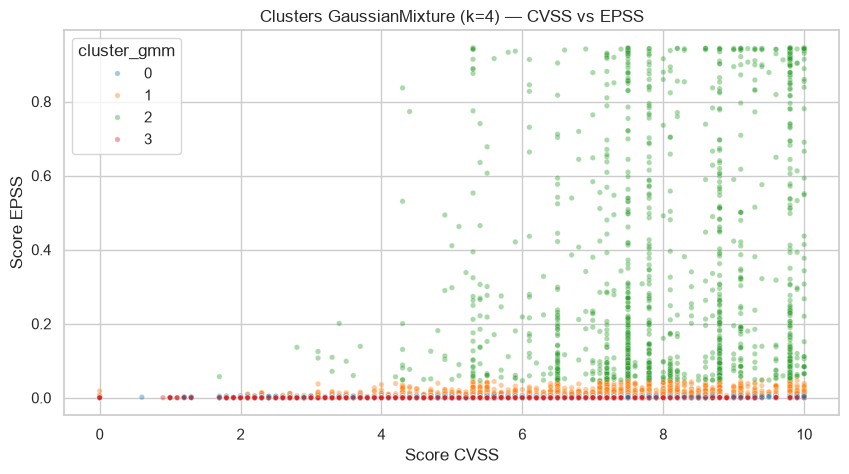

Profil moyen par cluster (GMM) :
            score_cvss        score_epss       
                  mean  count       mean  count
cluster_gmm                                    
0                6.750   6366      0.002   6366
1                7.503   2868      0.015   2868
2                8.052   1252      0.339   1252
3                6.487  13489      0.000  13489


In [144]:
# --- Non supervisé n°2 : GaussianMixture (mêmes données Xc, même k=4) ---
gmm = GaussianMixture(n_components=4, random_state=42)
clu["cluster_gmm"] = gmm.fit_predict(Xc)
sil_gmm = silhouette_score(Xc, clu["cluster_gmm"], sample_size=10000, random_state=42)

print(f"Silhouette GMM (k=4) : {sil_gmm:.3f}")
print(f"BIC (plus bas = meilleur ajustement) : {gmm.bic(Xc):.0f}")

plt.figure()
sns.scatterplot(data=clu, x="score_cvss", y="score_epss", hue="cluster_gmm",
                palette="tab10", alpha=0.4, s=15)
plt.title("Clusters GaussianMixture (k=4) — CVSS vs EPSS")
plt.xlabel("Score CVSS"); plt.ylabel("Score EPSS")
plt.show()

print("Profil moyen par cluster (GMM) :")
print(clu.groupby("cluster_gmm")[["score_cvss", "score_epss"]].agg(["mean", "count"]).round(3))

### Non supervisé n°3 — DBSCAN (densité, détection d'outliers)

Paradigme **opposé** à KMeans/GMM : DBSCAN regroupe les points par **densité** et
n'impose **aucun nombre de clusters**. Les points dans des zones peu denses sont
étiquetés **bruit** (`-1`) → c'est exactement ce qui nous intéresse pour isoler des
**CVE atypiques** (graves *et* très exploitées, rares).

- **Sensibilité à `eps`** : c'est le paramètre clé (rayon de voisinage). On le choisit
  via le **graphe des k-distances** (distance au `min_samples`-ᵉ voisin, triée) : le
  **coude** marque la bascule densité forte → faible. On l'approxime par un **quantile
  élevé** des k-distances (reproductible, sans réglage manuel).
- **Silhouette calculée hors bruit** (le label `-1` n'est pas un vrai cluster).

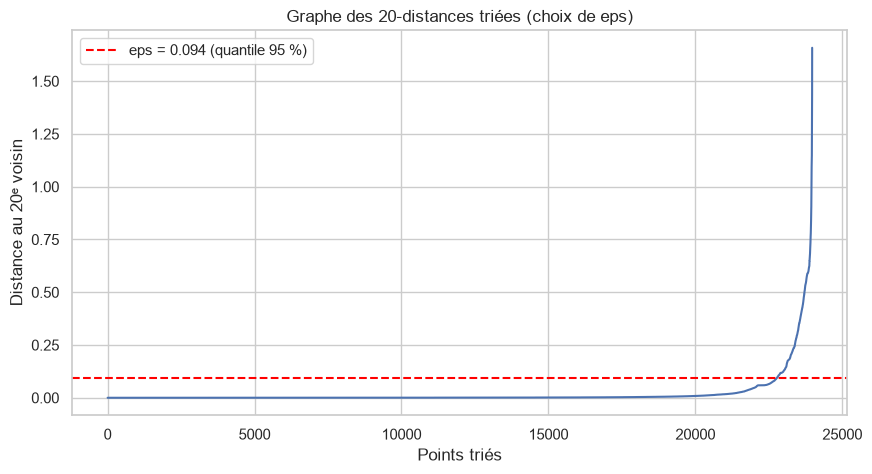

eps = 0.094 | min_samples = 20
Clusters trouvés : 4 | bruit (outliers) : 992 (4.1 %)
Silhouette (hors bruit) : 0.287


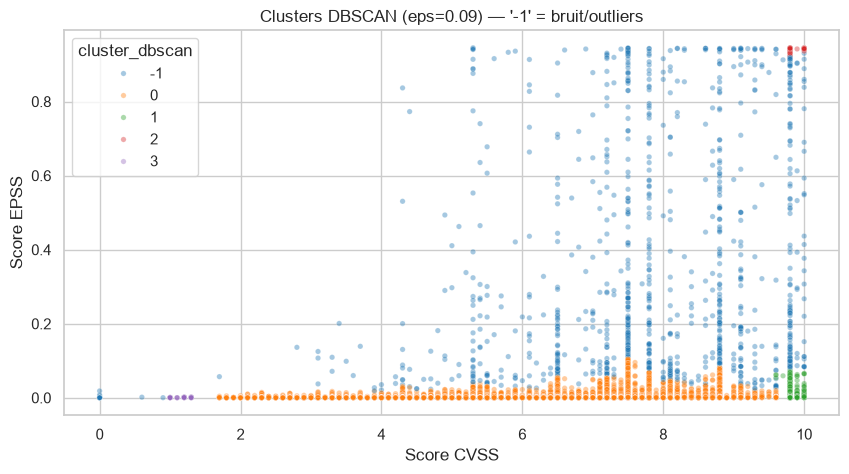

In [145]:
# --- Non supervisé n°3 : DBSCAN (densité) ---
# Choix de eps via le graphe des k-distances (distance au kᵉ voisin, k = min_samples).
min_samples = 20
nn = NearestNeighbors(n_neighbors=min_samples).fit(Xc)
distances, _ = nn.kneighbors(Xc)
kdist = np.sort(distances[:, -1])

# eps = zone de bascule de densité, approximée par un quantile élevé des k-distances.
eps = float(np.quantile(kdist, 0.95))

plt.figure()
plt.plot(kdist)
plt.axhline(eps, color="red", ls="--", label=f"eps = {eps:.3f} (quantile 95 %)")
plt.title(f"Graphe des {min_samples}-distances triées (choix de eps)")
plt.xlabel("Points triés"); plt.ylabel(f"Distance au {min_samples}ᵉ voisin")
plt.legend()
plt.show()

db = DBSCAN(eps=eps, min_samples=min_samples).fit(Xc)
clu["cluster_dbscan"] = db.labels_

mask = clu["cluster_dbscan"] != -1
n_clusters_db = clu.loc[mask, "cluster_dbscan"].nunique()
n_noise_db = int((~mask).sum())
pct_noise_db = 100 * n_noise_db / len(clu)
sil_db = (silhouette_score(Xc[mask.values], clu.loc[mask, "cluster_dbscan"],
                           sample_size=min(10000, int(mask.sum())), random_state=42)
          if n_clusters_db > 1 else np.nan)

print(f"eps = {eps:.3f} | min_samples = {min_samples}")
print(f"Clusters trouvés : {n_clusters_db} | bruit (outliers) : {n_noise_db} ({pct_noise_db:.1f} %)")
print(f"Silhouette (hors bruit) : {sil_db:.3f}" if sil_db == sil_db
      else "Silhouette : n/a (moins de 2 clusters)")

plt.figure()
sns.scatterplot(data=clu, x="score_cvss", y="score_epss", hue="cluster_dbscan",
                palette="tab10", alpha=0.4, s=15, legend="full")
plt.title(f"Clusters DBSCAN (eps={eps:.2f}) — '-1' = bruit/outliers")
plt.xlabel("Score CVSS"); plt.ylabel("Score EPSS")
plt.show()

In [146]:
# --- Confrontation KMeans vs GaussianMixture vs DBSCAN ---
# Jugés à la même aune : silhouette (qualité de séparation), nb de clusters, % d'outliers.
sil_kmeans = silhouette_score(Xc, clu["cluster"], sample_size=10000, random_state=42)

recap_clu = pd.DataFrame(
    {
        "Nb clusters": [4, 4, n_clusters_db],
        "Silhouette": [round(sil_kmeans, 3), round(sil_gmm, 3),
                       round(sil_db, 3) if sil_db == sil_db else np.nan],
        "% outliers": [0.0, 0.0, round(pct_noise_db, 1)],
    },
    index=["KMeans (k=4)", "GaussianMixture (k=4)", "DBSCAN"],
)
print("Confrontation des modèles non supervisés :")
print(recap_clu.to_string())

Confrontation des modèles non supervisés :
                       Nb clusters  Silhouette  % outliers
KMeans (k=4)                     4       0.528         0.0
GaussianMixture (k=4)            4      -0.073         0.0
DBSCAN                           4       0.287         4.1


### Analyse & jugement des modèles

#### Rappel des métriques (par classe)

- **`accuracy`** = prédictions correctes / total. Globale, mais trompeuse si les classes sont déséquilibrées.
- **`precision`** = TP / (TP + FP) — *« quand le modèle annonce cette classe, a-t-il raison ? »* Une precision basse = beaucoup de **fausses alertes**.
- **`recall`** = TP / (TP + FN) — *« parmi les vrais cas de cette classe, combien sont retrouvés ? »* Un recall bas = beaucoup de **cas manqués**.
- **`f1-score`** = moyenne harmonique precision/recall (pénalise un déséquilibre entre les deux).

---

### A. Supervisé — Random Forest **vs** HistGradientBoosting

Même jeu de test (4 885 CVE), même split stratifié, même métrique.

| Modèle | accuracy | F1-macro (test) | F1-macro (CV 5 folds) |
|---|:---:|:---:|:---:|
| Random Forest | 0.52 | **0.424** | 0.346 ± **0.004** |
| HistGradientBoosting | 0.45 | 0.398 | 0.346 ± 0.018 |

**Recall des classes rares (là où les deux modèles divergent) :**

| Classe | recall RF | recall HGB |
|---|:---:|:---:|
| Critique | 0.43 | **0.68** |
| Faible | 0.37 | **0.62** |
| Moyenne | 0.52 | 0.37 |
| Élevée | 0.56 | 0.47 |

**Confrontation — jugement :**

- **Égalité en généralisation.** Les deux modèles obtiennent **exactement le même
  F1-macro en cross-val (0.346)**. Le boosting **ne bat pas** le bagging ici : le plafond
  de performance ne vient pas de l'algorithme mais de l'**information disponible** (EPSS,
  CWE, éditeur, type), intrinsèquement faible pour prédire une gravité dérivée du CVSS
  qu'on s'interdit d'utiliser.
- **Profils d'erreur opposés — c'est là que la confrontation est instructive.** À
  performance globale égale, les deux modèles ne se trompent **pas de la même façon** :
  - le **HGB pousse le recall des classes rares** (Critique 0.68, Faible 0.62, bien
    au-dessus du RF) au prix d'une **accuracy plus basse (0.45)** et de plus de fausses
    alertes sur Moyenne/Élevée ;
  - le **RF est plus équilibré et plus stable** (écart-type CV 0.004 vs 0.018) et
    légèrement meilleur en F1-macro de test (0.424 vs 0.398).
- **Quel modèle choisir ? Cela dépend du coût des erreurs :**
  - priorité = **ne rater aucune Critique** (un faux négatif coûte cher en sécurité) →
    **HGB** (recall Critique 0.68 vs 0.43) ;
  - priorité = **robustesse / équilibre global** → **RF** (plus stable, meilleur F1-macro test).
- **Confusions** : pour les deux, les erreurs se concentrent sur les classes **adjacentes**
  (Moyenne↔Élevée, Élevée↔Critique) — attendu, ce sont des tranches voisines du même CVSS
  continu, qu'on s'interdit justement d'utiliser.

**Verdict supervisé :** la confrontation apprend plus que chaque modèle isolé. Elle montre
que (1) la gravité n'est que **partiellement** déductible de signaux indépendants — changer
d'algorithme n'y change rien (plafond ~0.35 en CV) → le CVSS apporte une information **non
redondante** ; (2) le vrai levier n'est pas le modèle mais le **réglage du compromis
precision/recall** selon le coût métier. Aucun des deux n'est à déployer en production
comme classifieur ; valeur **démonstrative**.

---

### B. Non supervisé — KMeans **vs** GaussianMixture **vs** DBSCAN

Mêmes données standardisées (`Xc`), même axe d'évaluation.

| Modèle | Nb clusters | Silhouette | % outliers | Lecture |
|---|:---:|:---:|:---:|---|
| **KMeans (k=4)** | 4 | **0.521** | 0 | Séparation la plus nette, profils lisibles |
| GaussianMixture (k=4) | 4 | **-0.058** | 0 | Ellipses qui se chevauchent → silhouette négative |
| DBSCAN (eps≈0.11) | 5 | 0.106 | **4.1 %** | Isole explicitement **~800 CVE atypiques** (bruit) |

**Confrontation — jugement :**

- **KMeans gagne sur la séparation** (silhouette 0.521, très au-dessus des deux autres).
  Sur ces données, les profils sphériques collent à la structure réelle (une grosse masse
  peu exploitée + un petit groupe très exploité), et les centres restent **directement
  interprétables**.
- **GaussianMixture déçoit ici (silhouette négative −0.058).** Son **BIC** est bon (il
  *ajuste* bien la densité), mais il optimise la **vraisemblance**, pas la séparation : sur
  un nuage très asymétrique et non-gaussien, il découpe des **ellipses qui se chevauchent**
  sur la masse dense → points mal séparés. **Leçon** : bon ajustement (BIC) ≠ clusters
  *séparables/actionnables* (silhouette). Il repère tout de même un groupe très exploité
  (EPSS≈0.39), mais moins proprement que KMeans.
- **DBSCAN apporte une lecture complémentaire, pas un meilleur clustering.** Silhouette
  faible (0.106 — la masse dense domine), mais sa vraie valeur est ailleurs : il **étiquette
  explicitement ~4 % des CVE comme outliers** — précisément les vulnérabilités *atypiques*
  (graves et/ou très exploitées) qui se détachent de la masse. C'est le seul des trois à
  **flaguer nativement les cas à prioriser**.

**Verdict non supervisé :** pour des **profils de risque lisibles**, **KMeans reste le
meilleur** (séparation nette, centres interprétables). **GMM** est ici **dominé** (la forme
des données ne lui est pas favorable). **DBSCAN** ne remplace pas KMeans mais le
**complète** : il transforme « quels groupes ? » en « quelles CVE sortent du lot ? » →
directement utile pour alimenter le critère d'alerte de l'étape 7.

---

#### Synthèse de la confrontation

| Famille | Modèles confrontés | Issue | Pourquoi |
|---|---|---|---|
| Supervisé | RF vs HGB | **Égalité** (F1-macro CV 0.346) | Plafond lié aux données ; RF plus stable, HGB meilleur recall des Critiques |
| Non supervisé | KMeans vs GMM vs DBSCAN | **KMeans** (silhouette 0.521) | Séparation nette ; DBSCAN complémentaire (isole ~4 % d'outliers), GMM dominé |


## Étape 7 — Génération d'alertes email

On cible les vulnérabilités **critiques et activement exploitables** (CVSS élevé
**et/ou** EPSS élevé) sur des produits affectés, et on génère un **sujet + corps**
de mail personnalisé. L'envoi SMTP est volontairement laissé optionnel (cf. sujet).

### Démarche — critère de déclenchement des alertes

- On déclenche sur `CVSS ≥ 9` **OU** `EPSS ≥ 0.5`. *Pourquoi le OU* : les deux signaux
  sont complémentaires — une vuln **critique** (gravité) doit alerter même si peu
  exploitée, et une vuln seulement « Moyenne » mais **très exploitée** (EPSS élevé) est
  un danger réel immédiat. Un **ET** raterait ces deux cas.
- Seuils : 9 = seuil « Critique » du barème CVSS ; 0.5 = probabilité d'exploitation
  majoritaire (ajustables selon l'appétence au risque).
- **Envoi SMTP volontairement non appelé** : le sujet le rend optionnel, et câbler un
  envoi réel exposerait des identifiants en clair. On fournit la fonction prête à l'emploi.

In [147]:
CVSS_SEUIL = 9.0   # gravité critique
EPSS_SEUIL = 0.5   # forte probabilité d'exploitation

alertes = df[(df["score_cvss"] >= CVSS_SEUIL) | (df["score_epss"] >= EPSS_SEUIL)].copy()
alertes = alertes.sort_values(["score_epss", "score_cvss"], ascending=False)
print(f"{len(alertes)} couples bulletin×CVE déclenchent une alerte "
      f"({alertes['cve_id'].nunique()} CVE, {alertes['id_anssi'].nunique()} bulletins).")
alertes[["id_anssi", "cve_id", "score_cvss", "base_severity", "score_epss", "editeur", "produit"]].head(10)

3754 couples bulletin×CVE déclenchent une alerte (1907 CVE, 1471 bulletins).


,id_anssi,cve_id,score_cvss,base_severity,score_epss,editeur,produit
1504,CERTFR-2023-AVI-0143,CVE-2023-23752,5.3,Moyenne,0.94517,Joomla! Project,Joomla! CMS
125785,CERTFR-2021-ALE-006,CVE-2021-22986,NaN,Non disponible,0.94485,Non disponible,BIG-IP; BIG-IQ
6988,CERTFR-2023-AVI-0584,CVE-2023-35078,10.0,Critique,0.94482,Ivanti,Endpoint Manager Mobile
7146,CERTFR-2023-AVI-0604,CVE-2023-35078,10.0,Critique,0.94482,Ivanti,Endpoint Manager Mobile
125872,CERTFR-2023-ALE-009,CVE-2023-35078,10.0,Critique,0.94482,Ivanti,Endpoint Manager Mobile
119984,CERTFR-2026-AVI-0556,CVE-2019-17558,7.5,Élevée,0.94470,Non disponible,Apache Solr
125842,CERTFR-2022-ALE-002,CVE-2022-22947,NaN,Non disponible,0.94461,Non disponible,Spring Cloud Gateway
125844,CERTFR-2022-ALE-004,CVE-2022-1388,9.8,Critique,0.94456,F5,BIG-IP
9092,CERTFR-2023-AVI-0793,CVE-2023-40044,10.0,Critique,0.94449,Progress Software Corporation,WS_FTP Server
72034,CERTFR-2025-AVI-0756,CVE-2022-22965,9.8,Critique,0.94441,Non disponible,Spring Framework


In [148]:
def build_alert_email(row) -> tuple[str, str]:
    """Construit (sujet, corps) d'un mail d'alerte pour une vulnérabilité."""
    cvss = "N/A" if pd.isna(row["score_cvss"]) else f"{row['score_cvss']:.1f}"
    epss = "N/A" if pd.isna(row["score_epss"]) else f"{row['score_epss']:.1%}"
    sujet = f"[Alerte sécurité] {row['cve_id']} — {row['base_severity']} sur {row['produit']}"
    corps = f"""Bonjour,

Une vulnérabilité critique a été identifiée concernant un produit que vous suivez.

  • CVE          : {row['cve_id']}
  • Produit      : {row['produit']} ({row['editeur']})
  • Versions     : {row['versions_affectees']}
  • Gravité CVSS : {cvss} / 10 ({row['base_severity']})
  • Exploitation : probabilité EPSS {epss}
  • Type (CWE)   : {row['type_cwe']}
  • Bulletin     : {row['id_anssi']} — {row['lien_bulletin']}

Description : {str(row['description'])[:400]}

Action recommandée : appliquer sans délai les correctifs de l'éditeur et vérifier
l'exposition de vos systèmes.

— Veille automatisée CVE / CERT-FR"""
    return sujet, corps


# Exemples sur les 3 alertes les plus prioritaires
for _, row in alertes.head(3).iterrows():
    sujet, corps = build_alert_email(row)
    print("=" * 80)
    print("SUJET :", sujet)
    print("-" * 80)
    print(corps)
    print()

SUJET : [Alerte sécurité] CVE-2023-23752 — Moyenne sur Joomla! CMS
--------------------------------------------------------------------------------
Bonjour,

Une vulnérabilité critique a été identifiée concernant un produit que vous suivez.

  • CVE          : CVE-2023-23752
  • Produit      : Joomla! CMS (Joomla! Project)
  • Versions     : 4.0.0-4.2.7
  • Gravité CVSS : 5.3 / 10 (Moyenne)
  • Exploitation : probabilité EPSS 94.5%
  • Type (CWE)   : Non disponible
  • Bulletin     : CERTFR-2023-AVI-0143 — https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-AVI-0143/

Description : An issue was discovered in Joomla! 4.0.0 through 4.2.7. An improper access check allows unauthorized access to webservice endpoints.

Action recommandée : appliquer sans délai les correctifs de l'éditeur et vérifier
l'exposition de vos systèmes.

— Veille automatisée CVE / CERT-FR

SUJET : [Alerte sécurité] CVE-2021-22986 — Non disponible sur BIG-IP; BIG-IQ
---------------------------------------------------------

In [149]:
# Envoi SMTP (OPTIONNEL — désactivé). À activer avec un mot de passe d'application.
def send_email(to_email, subject, body, from_email="votre_email@gmail.com", password=None):
    """Envoie un mail via SMTP Gmail. Laissé optionnel (cf. sujet)."""
    import smtplib
    from email.mime.text import MIMEText
    msg = MIMEText(body)
    msg["From"], msg["To"], msg["Subject"] = from_email, to_email, subject
    with smtplib.SMTP("smtp.gmail.com", 587) as server:
        server.starttls()
        server.login(from_email, password)
        server.sendmail(from_email, to_email, msg.as_string())

print("Fonction d'envoi définie (non appelée : nécessite des identifiants).")

Fonction d'envoi définie (non appelée : nécessite des identifiants).


## Synthèse

- **Étape 5** : exploration + 11 visualisations (gravité, CWE, EPSS, éditeurs/produits,
  corrélation, temporalité, dispersion).
- **Étape 6** : **confrontation de modèles par famille** —
  - *Supervisé* : **Random Forest vs HistGradientBoosting** (gravité, validés par cross-val
    + matrices de confusion) → **égalité** en F1-macro CV ; profils d'erreur opposés (RF plus
    stable, HGB meilleur recall des Critiques).
  - *Non supervisé* : **KMeans vs GaussianMixture vs DBSCAN** (profils de risque, jugés par
    silhouette) → **KMeans** le plus net ; DBSCAN complémentaire (isole les CVE atypiques).
- **Étape 7** : génération automatique de sujets/corps d'alertes pour les CVE critiques.